# Import Libraries

In [135]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import pickle

In [136]:
data = pd.read_csv('/content/netflix-stock-price/NFLX.csv')
data

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900
...,...,...,...,...,...,...,...
1004,2022-01-31,401.970001,427.700012,398.200012,427.140015,427.140015,20047500
1005,2022-02-01,432.959991,458.480011,425.540009,457.130005,457.130005,22542300
1006,2022-02-02,448.250000,451.980011,426.480011,429.480011,429.480011,14346000
1007,2022-02-03,421.440002,429.260010,404.279999,405.600006,405.600006,9905200


## About this Dataset - Netflix Stock Price(5th Feb 2018 to 5th Feb 2022)

This dataset includes historical stock price data of Netflix. This dataset typically contains daily stock trading data. Each row represents one trading day. Columns are:

Date -	The trading date. <br>
Open -	The stock price at the start of the trading day. <br>
High -	The highest price the stock reached during that day.<br>
Low	- The lowest price during that trading day.<br>
Close	- The stock price at the end of the trading day<br>
Adj Close	- Adjusted closing price (after dividends/splits)<br>
Volume - Total number of shares traded that day

Since we're NOT using time series, we're treating this like a normal supervised ML problem.

So our typical target variable will be either 'Close' or 'Adj Close'.

In [137]:
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900


In [138]:
data.shape

(1009, 7)

In [139]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1009 non-null   object 
 1   Open       1009 non-null   float64
 2   High       1009 non-null   float64
 3   Low        1009 non-null   float64
 4   Close      1009 non-null   float64
 5   Adj Close  1009 non-null   float64
 6   Volume     1009 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 55.3+ KB


In [140]:
data.dtypes

,0
Date,object
Open,float64
High,float64
Low,float64
Close,float64
Adj Close,float64
Volume,int64


# Missing values and Duplicates

In [141]:
print("Number of duplicates:", data.duplicated().sum())

Number of duplicates: 0


In [142]:
data.isna().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


# Data Cleaning

In [143]:
data['Date'] = pd.to_datetime(data['Date'])

In [144]:
data.dtypes

,0
Date,datetime64[ns]
Open,float64
High,float64
Low,float64
Close,float64
Adj Close,float64
Volume,int64


In [145]:
data.sort_values('Date', inplace=True)

In [146]:
data

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900
...,...,...,...,...,...,...,...
1004,2022-01-31,401.970001,427.700012,398.200012,427.140015,427.140015,20047500
1005,2022-02-01,432.959991,458.480011,425.540009,457.130005,457.130005,22542300
1006,2022-02-02,448.250000,451.980011,426.480011,429.480011,429.480011,14346000
1007,2022-02-03,421.440002,429.260010,404.279999,405.600006,405.600006,9905200


In [147]:
data.reset_index(drop=True, inplace=True)

In [148]:
data

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900
...,...,...,...,...,...,...,...
1004,2022-01-31,401.970001,427.700012,398.200012,427.140015,427.140015,20047500
1005,2022-02-01,432.959991,458.480011,425.540009,457.130005,457.130005,22542300
1006,2022-02-02,448.250000,451.980011,426.480011,429.480011,429.480011,14346000
1007,2022-02-03,421.440002,429.260010,404.279999,405.600006,405.600006,9905200


# Summary Statistics

In [149]:
data.describe()

,Date,Open,High,Low,Close,Adj Close,Volume
count,1009,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1.009000e+03
mean,2020-02-05 07:30:58.870168320,419.059673,425.320703,412.374044,419.000733,419.000733,7.570685e+06
min,2018-02-05 00:00:00,233.919998,250.649994,231.229996,233.880005,233.880005,1.144000e+06
25%,2019-02-06 00:00:00,331.489990,336.299988,326.000000,331.619995,331.619995,4.091900e+06
50%,2020-02-06 00:00:00,377.769989,383.010010,370.880005,378.670013,378.670013,5.934500e+06
75%,2021-02-05 00:00:00,509.130005,515.630005,502.529999,509.079987,509.079987,9.322400e+06
max,2022-02-04 00:00:00,692.349976,700.989990,686.090027,691.690002,691.690002,5.890430e+07
std,NaN,108.537532,109.262960,107.555867,108.289999,108.289999,5.465535e+06


In [150]:
mean = data['Volume'].mean()
std = data['Volume'].std()
min_val = data['Volume'].min()
max_val = data['Volume'].max()
q25 = data['Volume'].quantile(0.25)
q50 = data['Volume'].quantile(0.50) # Median
q75 = data['Volume'].quantile(0.75)

print(f"Mean: {mean}, Std: {std}, Min: {min_val}, Max: {max_val}")
print(f"25%: {q25}, 50%: {q50}, 75%: {q75}")

Mean: 7570685.03468781, Std: 5465535.2256899765, Min: 1144000, Max: 58904300
25%: 4091900.0, 50%: 5934500.0, 75%: 9322400.0


1️⃣ COUNT — Data Completeness & Structural Integrity

1009 trading days ≈ 4 years of market data (excluding weekends/holidays).

Every column has 1009 entries → no missing values.

<br>


2️⃣ MEAN — Central Tendency & Market Regime Insight


---


Date Mean = 2020-02-05

Dataset span:

- Min: 2018-02-05

- Max: 2022-02-04

Mean lies almost exactly in the middle → confirms evenly distributed time coverage.



---


💰 Price Means

Open	- 419.06

High	- 425.32

Low	- 412.37

Close	- 419.00

Adj Close	- 419.00

<br>

Key Comparative Observations:

1. Open ≈ Close

Difference = 0.05

Practically zero.

👉 No systematic intraday bias.
The stock does not consistently close higher or lower than it opens.

2. High - Low = 425.32 - 412.37 ≈ 13

- Average daily trading range ≈ $13.

Relative to mean price (419):

13/419 ≈ 3.1%

That’s moderate intraday volatility.

---

Adj Close = Close

From modeling standpoint:
You can drop either Close or Adj Close (they are redundant).

---

📊 Volume Mean = 7.57M

On average, 7.5 million shares traded daily.

---

3️⃣ MIN

Close	- 233.88

High	- 250.64

Low	- 231.23

Volume	- 1.14M


1. Price Perspective

Lowest close = 233
Highest close = 691

691/233≈2.96

Netflix nearly tripled over this period.

2. Volume Perspective

Minimum volume = 1.14M
Mean volume = 7.57M

1.14/7.57≈15%

Very low liquidity days exist, but rare.

---

4️⃣ 25% (First Quartile)

Close = 331.62

Meaning:
25% of days had price below 331.

Now compare:

Min = 233

25% = 331

Median = 378

The lower half of distribution is compressed.

---

5️⃣ 50% (Median) — Distribution Shape

Median Close = 378.67
Mean Close = 419.00

Mean > Median by ≈ 40.

That is a right-skewed distribution.

---

6️⃣ 75% (Third Quartile)

Close = 509.08

Now compare:

Median = 378

75% = 509

That’s a jump of 131(509-378) dollars.

Distribution stretches more in upper range.

Upper tail is much heavier.

---

7️⃣ MAX — Peak Behavior

Close Max = 691.69
High Max = 700.99

Difference ≈ 9 dollars.

This suggests:

Price often closed near daily high during peak phases.

Volume Max = 58.9M

Compare:

Mean = 7.57M

Max = 58.9M

58.9/7.57≈7.8

Almost 8x average.

Volume is extremely right-skewed.

# Outlier Detection

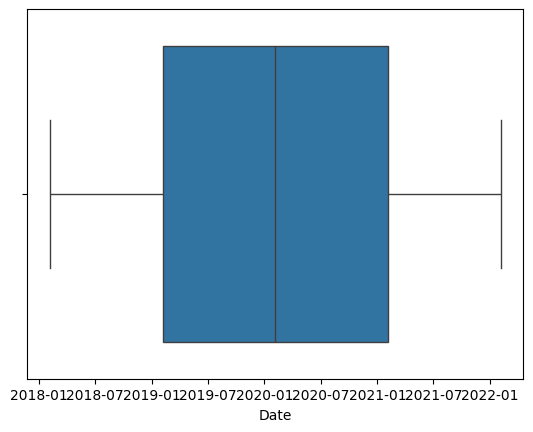

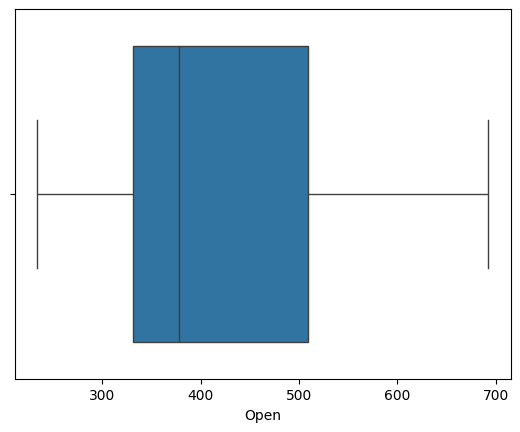

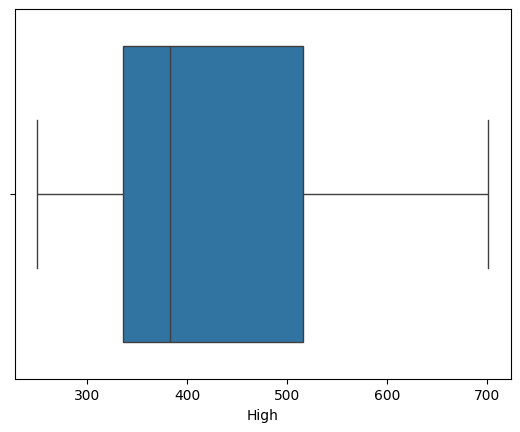

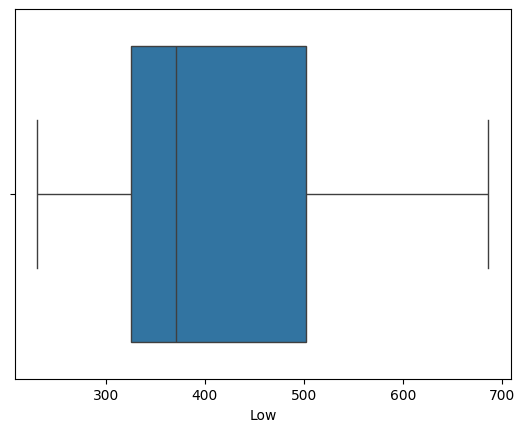

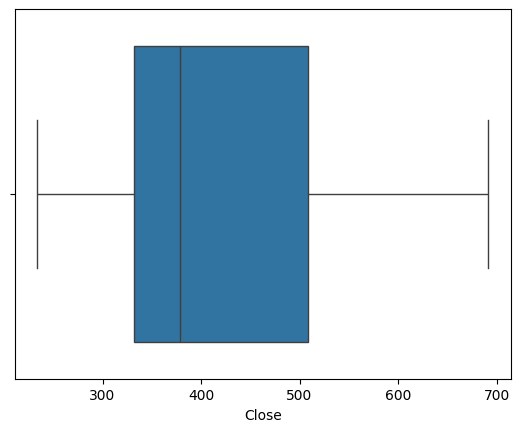

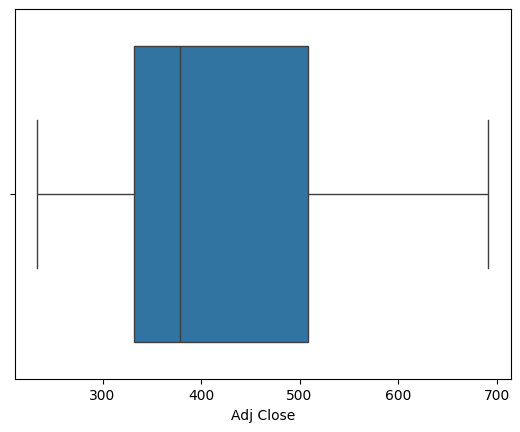

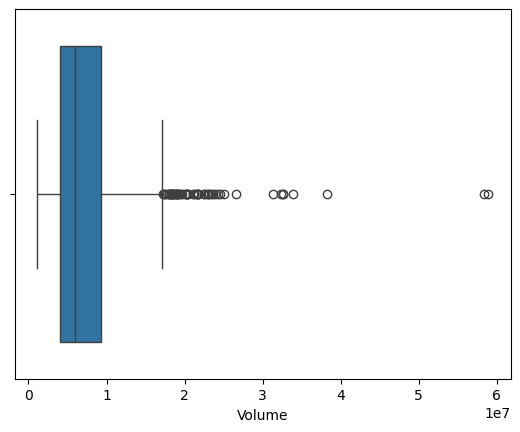

In [151]:
cols = list(data.columns)
for col in cols:
    sns.boxplot(x=data[col])
    plt.show()

1️⃣ Date Boxplot

- Symmetrical distribution across timeline

- Median roughly centered

- Insight:

  - No irregular time gaps.
  - Data evenly distributed across years.

- Good structural integrity.

---

2️⃣ Open Price Boxplot

- Box spans roughly 330 → 510

- Median ≈ 378

- Whiskers extend to ≈ 233 (min) and ≈ 692 (max)

- No visible extreme outliers

- The distribution is wide but smooth.

- No abnormal spikes beyond whiskers.

- This indicates:

  - Gradual long-term trend

  - No isolated erroneous values

- This is NOT “error outliers” — this is natural market growth.

- Similarly metrics like High, close, Low, adj close have same shape of boxplots

---

3️⃣ Volume Boxplot (Very Important)

- Box concentrated near lower values

- Many dots to the right

- Extreme outliers reaching 50M+

- Volume distribution is highly right-skewed.

- Volume is between 4M – 9M

- Extremely high volume (30M – 60M)

- These are likely:

  - Earnings announcements

  - COVID crash

  - Major company news

# Are These Outliers Errors?

For price variables:

No.

These are structural time-trend effects.

---

For volume:

No.

These are real event-driven spikes.

<br>

In stock data:
Outliers are often meaningful, not noise.

Removing them blindly would be wrong.

<br>

The price variables show wide but smooth distributions without abnormal statistical outliers, indicating natural market growth rather than noise. All price metrics share similar distribution shapes, confirming strong multicollinearity. Volume exhibits heavy right skew with extreme event-driven spikes, suggesting non-normal behavior and the need for transformation before modeling.

# Data Analysis

## 1. Univariate Analysis

### 1.1 Distribution of Closing Price

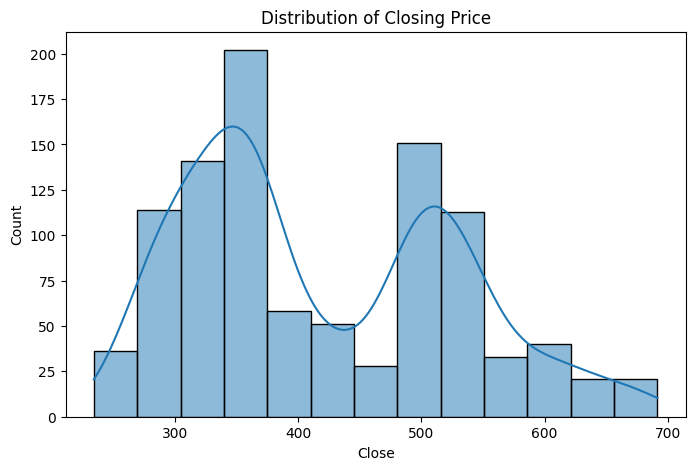

In [152]:
plt.figure(figsize=(8,5))
sns.histplot(data['Close'], kde=True)
plt.title("Distribution of Closing Price")
plt.show()

The distribution is NOT normal. Instead, it looks bimodal (two peaks).

- One peak around 300–380

- Another peak around 480–520

The stock had two dominant price regimes.

---

### Why Is It Bimodal?

Because your dataset spans multiple market phases:

📌 Phase 1 (2018–2019)

Price mostly between:
300–380

📌 Phase 2 (2020–2021 rally)

Price mostly between:
480–550

---

Look at the right tail, it stretches toward 600–700. Now compare with summary stats:

Mean = 419

Median = 378

Mean > Median

Confirms right skew.

---

Prices range approximately:

250 → 700

That is a very wide range.

This large range explains why:

Std ≈ 108 (which we discussed earlier)

High standard deviation = wide histogram.

---
### What This Means for Modeling

This distribution tells us:

1. Linear regression on raw prices may struggle because Relationship may not be stable across regimes.

2. Time-aware splitting is critical i.e. If you randomly split, Model may learn high-price regime and predict low-price regime.

That causes leakage-like effect.

---

The distribution of closing prices is bimodal, reflecting two distinct market regimes during the 4-year period. The data is right-skewed due to high price levels during the 2021 rally. The wide spread confirms significant volatility, and the non-normal shape indicates non-stationary behavior, which has implications for regression modeling.

### 1.2 Distribution of Volume

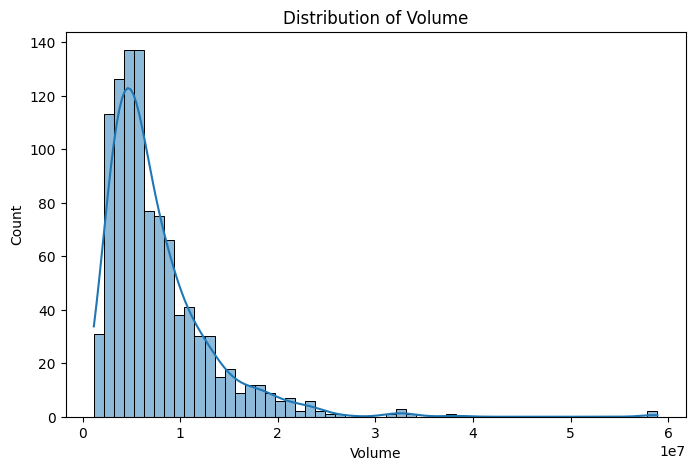

In [153]:
plt.figure(figsize=(8,5))
sns.histplot(data['Volume'], kde=True)
plt.title("Distribution of Volume")
plt.show()

The distribution is highly right-skewed (positively skewed).

What does that mean?

- Most values are concentrated on the left (lower volume).

- A long tail stretches toward the right (very high volume days).

This is NOT a normal distribution.

---

Most trading days fall roughly between: 3 million – 10 million shares

This matches your summary stats:

Mean ≈ 7.57M

Median ≈ ~5.9M (from describe earlier)

Since Mean > Median, this confirms right skew.

---

a long thin tail extending up to ~60 million shares. Those are extreme volume days. In stock markets, high volume days are usually caused by:

- Earnings announcements

- Major news

- COVID crash period

- Regulatory issues

- Large institutional trading

These are NOT errors.
These are meaningful market events.

---

Since volume is heavily skewed:

🚨 Problem:

Linear regression assumes:

- Errors are normally distributed.

- Features roughly symmetric (preferably).

- Skewed volume may:

- Distort model

- Reduce stability

So we need to do log transformation on volume column to:
- compresses large values

- Makes distribution more symmetric

- Reduces effect of extreme spikes

---

Price - Slightly right skew - volatility is moderate

Volume - Extremely right skew - volatility is Very High

---

### Does Volume Predict Price?

Volume alone usually has weak linear correlation with price but Volume spikes often align with volatility spikes.

Better feature:

df['Volatility'] = df['High'] - df['Low']

Then check correlation between Volume and Volatility.

You’ll likely see stronger relationship.

---

🌊 What is Volatility?

Volatility measures how much a price moves up and down over time.

If price changes a lot → High volatility
If price moves smoothly → Low volatility

It measures instability / uncertainty / risk.

Better way to measure true volatility:

👉 Use returns, not raw prices.

Price has upward trend.

But volatility measures fluctuation, not growth.

```
df['Daily_Return'] = df['Close'].pct_change()
```

Volatility = Standard deviation of returns.

Volatility=Std(Daily Returns)

```
volatility = df['Daily_Return'].std()
print(volatility)
```

The volume distribution is highly right-skewed with a long heavy tail, indicating that most trading days experience moderate activity while a few event-driven days show extreme spikes. Due to this skewness, log transformation is recommended before modeling.

In [154]:
data_new = data.copy()

In [155]:
data_new['Daily_Return'] = data_new['Close'].pct_change()
volatility = data_new['Daily_Return'].std()
print(volatility)

0.026603267073561154


volatility result = 0.03, that means Average daily movement ≈ 3%.

## 2. Time-Based Analysis

### 2.1 Netflix Closing Price Over Time

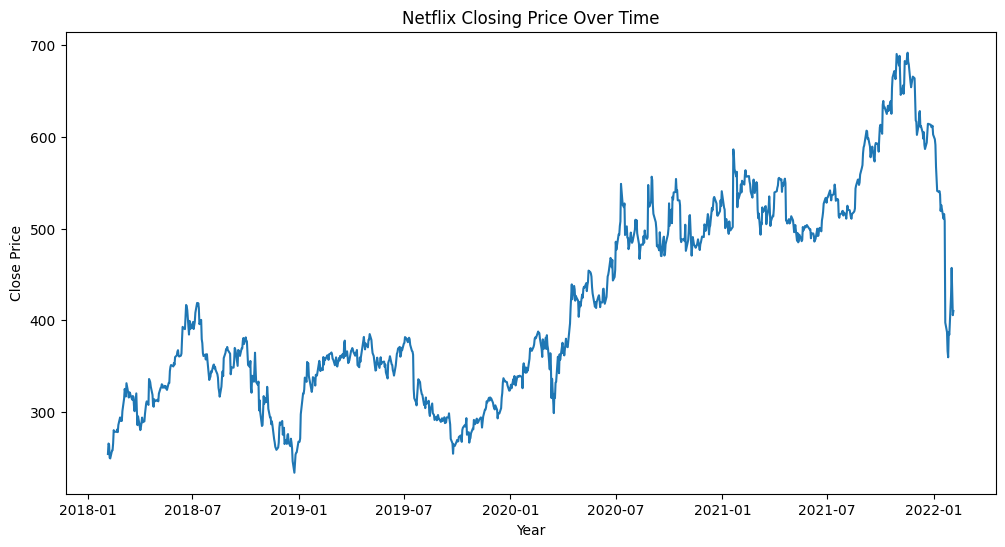

In [156]:
plt.figure(figsize=(12,6))
plt.plot(data_new['Date'], data_new['Close'])
plt.title("Netflix Closing Price Over Time")
plt.xlabel("Year")
plt.ylabel("Close Price")
plt.show()

Clear long-term upward trend from 2018 to late 2021.

Price moves from around:

~250 in 2018 to ~690 in late 2021

That’s almost 3x growth.

Insight:

This confirms:

✔ Strong structural growth

✔ Non-stationary time series

---

### Market Phases (Regime Analysis)

Let’s divide into phases.

📌 Phase 1: 2018 (Volatile but moderate range)

- Price fluctuates between:
250 – 420

- Lots of up and down movement.

- Moderate volatility.

<br>

📌 Phase 2: 2019 (Sideways / consolidation)

- Mostly trading between:
300 – 380

- This looks like a consolidation period.

- Less aggressive growth.

<br>

📌 Phase 3: 2020 (Major breakout)

- Around early 2020 you see sharp dip → COVID crash.

- Then huge rally.

- Price jumps from:
~300 → ~500+

This period shows:

🔥 High volatility

🔥 Strong bullish momentum

<br>

📌 Phase 4: 2021 (Peak phase)

- Price moves between:
500 – 690

- Large swings.
Eventually reaches peak around ~690.

<br>

📌 Phase 5: Early 2022 (Crash)

- Sharp drop from:
~690 → ~360

- That is massive correction.

- Volatility extremely high here.

---

🌊 3️⃣ Volatility Clustering

- Volatility is not constant.

- Small fluctuations (2019)

- Large swings (2020 and 2022)

This is called Volatility clustering

Financial markets often show High volatility followed by high volatility.

This violates constant variance assumption in linear regression.

---

The closing price shows a strong upward trend from 2018 to late 2021, followed by a sharp correction in early 2022. The series exhibits non-stationary behavior with changing mean and variance over time. Volatility clustering is visible, particularly during the COVID period and the 2022 crash. These characteristics imply that time-aware splitting and careful feature engineering are required before applying linear regression.

### 2.2 Daily Return

Daily Return tells you:

How much the stock moved (in percentage terms) compared to the previous day.

It measures relative change, not absolute change.

🔹 Why Daily Returns Are Important

1. Raw price:

- Has upward trend

- Mean changes over time

- Hard to model

2. Daily returns:

- Centered around 0

- More stable

- Better for volatility calculation

---

If Netflix goes:

400 → 420

Daily return:

(420−400)/400=0.05

That means:
5% gain in one day.

If next day:

420 → 390

(390−420)/420=−0.071

That means:
7.1% loss.

---

Daily return represents the percentage change in stock price from one trading day to the next. It is computed using the pct_change() function in pandas and is preferred over raw price changes because it normalizes movement relative to price level and provides a more stationary series for modeling and volatility analysis.

In [157]:
data_new.describe()

,Date,Open,High,Low,Close,Adj Close,Volume,Daily_Return
count,1009,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1.009000e+03,1008.000000
mean,2020-02-05 07:30:58.870168320,419.059673,425.320703,412.374044,419.000733,419.000733,7.570685e+06,0.000831
min,2018-02-05 00:00:00,233.919998,250.649994,231.229996,233.880005,233.880005,1.144000e+06,-0.217905
25%,2019-02-06 00:00:00,331.489990,336.299988,326.000000,331.619995,331.619995,4.091900e+06,-0.011933
50%,2020-02-06 00:00:00,377.769989,383.010010,370.880005,378.670013,378.670013,5.934500e+06,0.000673
75%,2021-02-05 00:00:00,509.130005,515.630005,502.529999,509.079987,509.079987,9.322400e+06,0.014544
max,2022-02-04 00:00:00,692.349976,700.989990,686.090027,691.690002,691.690002,5.890430e+07,0.168543
std,NaN,108.537532,109.262960,107.555867,108.289999,108.289999,5.465535e+06,0.026603


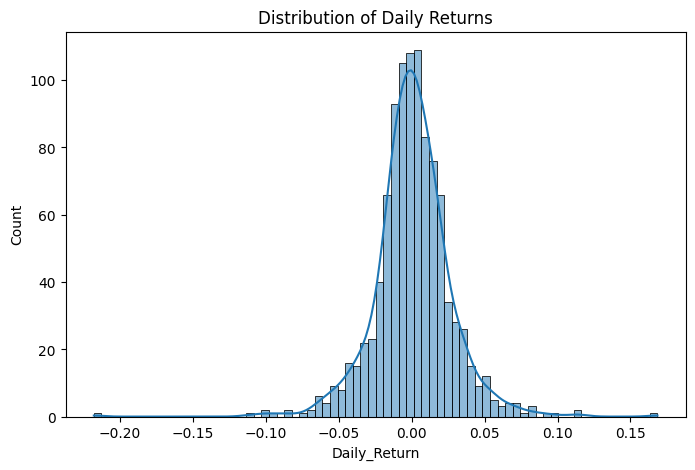

In [158]:
plt.figure(figsize=(8,5))
sns.histplot(data_new['Daily_Return'], kde=True)
plt.title("Distribution of Daily Returns")
plt.show()

The distribution is approximately bell-shaped Centered around 0.

This is VERY different from the price distribution.

### Center Around Zero

Most values lie between:

-0.03 and +0.03 (≈ -3% to +3%)

This means:

On most days, Netflix moves within ±3%.

That’s normal daily movement.

---

### Mean of Returns

Mean ≈ 0

Because:
Stock prices randomly move up and down.

---

### Tails (Very Important)

There are some extreme values:

Left tail ≈ -0.20 (−20%)

Right tail ≈ +0.16 (+16%)

These are rare but very large movements.

These likely correspond to:

- Earnings surprises

- COVID crash

- Major announcements

---

### Fat Tails

The distribution is:

✔ Mostly normal-like

✔ Tails are heavier than normal

This is common in financial markets.

It means:

Extreme events happen more often than normal distribution predicts.

This is called:

👉 “Fat-tailed distribution”

---

### Compare With Price Distribution

Price distribution:

- Bimodal

- Trend-driven

- Non-stationary

Return distribution:

- Centered at zero

- Much more symmetric

- More stationary

This is why finance modeling uses returns, not prices.

---

### Volatility Insight

Spread of histogram indicates volatility.

If most values are within ±3%,
and occasional ±10%,
that tells you:

Stock is moderately volatile.

The daily returns distribution is approximately symmetric and centered around zero, indicating no strong daily drift. However, the presence of heavy tails suggests occasional extreme movements, which are common in financial markets. Compared to raw prices, returns appear more stationary and are more suitable for volatility modeling and regression analysis.

## 3. Bivariate Analysis

### 3.1 Scatterplot Open vs Close

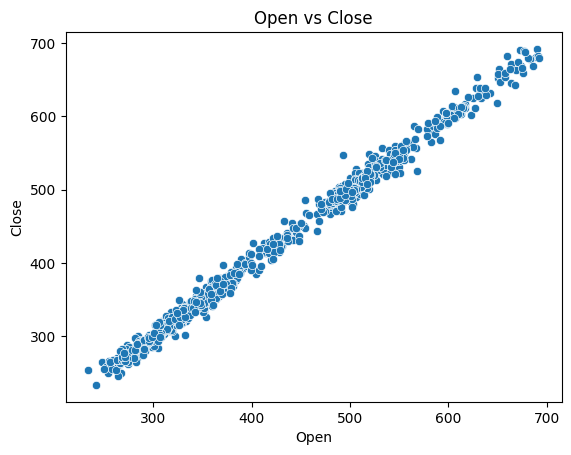

In [159]:
sns.scatterplot(x=data_new['Open'], y=data_new['Close'])
plt.title("Open vs Close")
plt.show()

Almost perfect straight line.
  
Close is strongly dependent on Open.

But using same-day Open may cause leakage

### 3.2 Scatterplot Volume vs Close

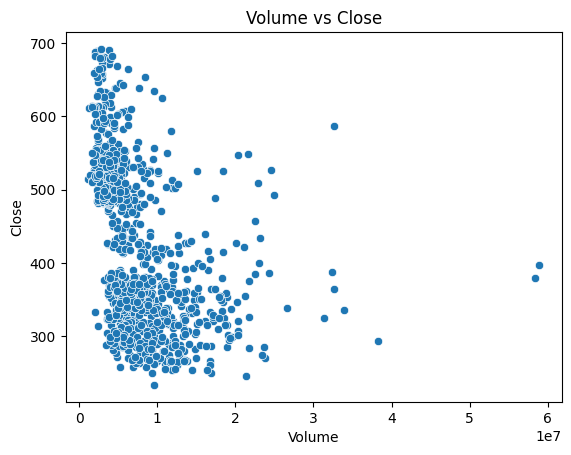

In [160]:
sns.scatterplot(x=data_new['Volume'], y=data_new['Close'])
plt.title("Volume vs Close")
plt.show()

No clear linear pattern.

Volume alone may not strongly predict price.

## 4. Multivariate Analysis

### 4.1 Correlation Matrix

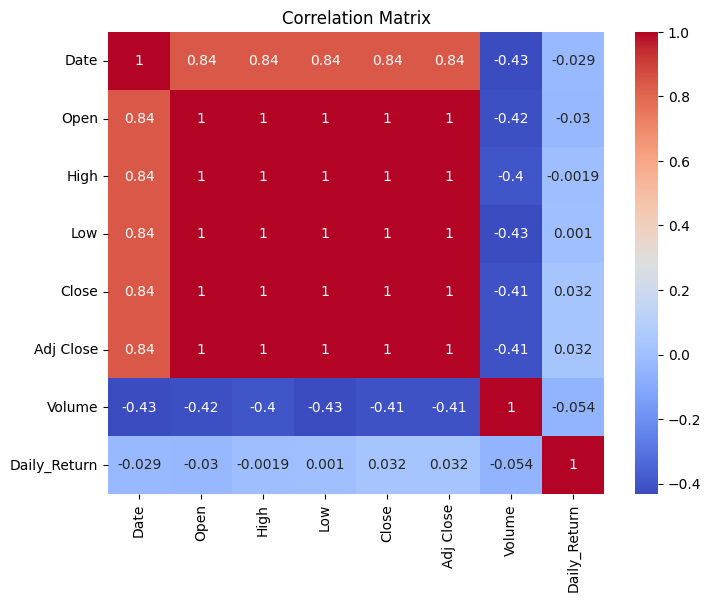

In [161]:
plt.figure(figsize=(8,6))
sns.heatmap(data_new.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

🔴 1️⃣ Price Variables (Open, High, Low, Close, Adj Close)

Look at the red block:

All correlations ≈ 1.00

That means:

Open ↔ High ≈ 1

Open ↔ Low ≈ 1

Open ↔ Close ≈ 1

Close ↔ Adj Close ≈ 1

🔥 What This Means

These variables move almost perfectly together.

This is called:

👉 Severe Multicollinearity

---

🚨 Why Multicollinearity is a Problem

In Linear Regression:

When predictors are highly correlated:

- Coefficients become unstable

- Model interpretation becomes meaningless

- Variance of coefficients increases

So if you include all price variables together, You’re basically giving the same information 5 times.

Price variables are redundant.

You should NOT use:

Open + High + Low + Close together.

Instead choose:

- Close only
or

- Use lag features

---

🟠 2️⃣ Date Correlation (~0.84 with Prices)

Date has ~0.84 correlation with price variables.

This is very interesting.

What does that mean?

It means:

As time increases → price increases.

---

🔵 3️⃣ Volume Correlation

Look at Volume correlations:

Volume ↔ Price ≈ -0.41 to -0.43

This is moderate negative correlation.

Interpretation:

When price is high → volume tends to be lower
When price drops → volume spikes

This often happens during:

Market crashes

Panic selling

So volume increases during volatility periods.

---

🟣 4️⃣ Daily_Return Correlation

Look at Daily_Return correlations:

Daily_Return ↔ Price ≈ near 0
Daily_Return ↔ Volume ≈ -0.054

That means:

Daily returns are almost uncorrelated with raw price.

This is expected.

### 4.2 Multicollinearity Check

In [162]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [163]:
X = data_new[['Open','High','Low','Close','Volume']]

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]

vif_data

,Feature,VIF
0,Open,12484.621420
1,High,16448.058736
2,Low,16178.223923
3,Close,12478.622308
4,Volume,3.218644


🔴 1️⃣ Price Variables (Open, High, Low, Close)

VIF > 12,000

This is not just high.
This is extreme multicollinearity.

What does that mean?

It means:

Each price variable can almost perfectly be predicted from the others.

So regression sees them as almost duplicates.

---

🟢 2️⃣ Volume (VIF = 3.21)

Volume has:

Low VIF.

Meaning:

Volume is not strongly linearly dependent on price variables.

So Volume is relatively independent feature.

---

📌 What Should You Do?

1. Removing Highly Correlated Features: Drop one of the correlated features.

```python
X = df[['Close','Volume']]
```

2. Use Lag Feature Instead

```python
df['Prev_Close'] = df['Close'].shift(1)
X = df[['Prev_Close','Volume']]
```
More realistic and avoids leakage.

## What is Data Leakage?

Data leakage happens when your model gets access to information that would NOT be available at prediction time.

It makes your model look extremely accurate… but it will fail in real-world deployment.

📊 In Your Netflix Dataset – Where Leakage Happens

Your dataset contains:

- Date

- Open

- High

- Low

- Close

- Adj Close

- Volume

If your goal is:

🎯 Predict today's Close

Then this becomes leakage:

Close = f(Open, High, Low, Volume)

Why?

Because:

- High = highest price during the day

- Low = lowest price during the day

- These values are only known AFTER market closes

So you're indirectly giving the answer to the model.

### 📈 Realistic Trading Flow

Imagine 9:15 AM market opens.

You know:

- Yesterday’s close

- Today's open

- Past trends

You DO NOT know:

- Today’s high

- Today’s low

- Today’s final close

So if you use High & Low of same day → leakage.

###🔥 Common Leakage Mistakes in Your Project

❌ 1. Using Same-Day Features

```python
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Close']
```

High correlation ≠ valid model.

<br>

❌ 2. Random Train-Test Split
```python
train_test_split(df, shuffle=True)
```

This mixes 2022 data into training when predicting 2018 data.

Stock data is time-dependent.

<br>

❌ 3. Using Future Data in Rolling Features

Wrong:

```python
df['MA_7'] = df['Close'].rolling(7).mean()
```

If not careful, it may include current day value in prediction.

<br>

### ✅ How to Properly Avoid Data Leakage

✅ Step 1: Use Only Past Information

If predicting today's Close:

Create lag features:

```python
df['Prev_Close'] = df['Close'].shift(1)
df['MA_7'] = df['Close'].shift(1).rolling(7).mean()
```

Key rule:

- Always use .shift(1) before rolling. This ensures Model only sees yesterday & earlier data

<br>

✅ Step 2: Drop Same-Day High/Low

```python
df = df.drop(['Open','High','Low','Adj Close'], axis=1)
```

Much more realistic.

<br>

✅ Step 3: Not to use Date directly

If you use date, this is a problem because:

- Date is just a timestamp.

- Linear regression will treat it as a large increasing number.

- It will simply learn the upward trend.

- It can cause overfitting to trend.

Instead of raw date, extract meaningful time features.

```python
df['Day_of_Week'] = df['Date'].dt.dayofweek
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
```
then drop original Date:

```python
df = df.drop('Date', axis=1)
```

✅ Step 4: Time-Based Train-Test Split

Never shuffle stock data.

Correct way:

```python
train_size = int(len(df)*0.8)
train = df[:train_size]
test = df[train_size:]
```

This simulates real-world prediction:

- Train on past

- Test on future

✅ Step 5: Be Careful with Scaling

Wrong:

```python
scaler.fit(df)
```

Correct:

```python
scaler.fit(train)
scaler.transform(train)
scaler.transform(test)
```

Otherwise test data influences scaling.

# Goal - Predict Next Day’s Closing Price using historical data up to today's time.

# Feature Engineering

In [164]:
# . By using shift(-1), you are aligning the target for today (row i) with the closing price of tomorrow (row i + 1)
data_new['Target'] = data_new['Close'].shift(-1)
data_new

,Date,Open,High,Low,Close,Adj Close,Volume,Daily_Return,Target
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100,NaN,265.720001
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800,0.045072,264.559998
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500,-0.004366,250.100006
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700,-0.054657,249.470001
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900,-0.002519,257.950012
...,...,...,...,...,...,...,...,...,...
1004,2022-01-31,401.970001,427.700012,398.200012,427.140015,427.140015,20047500,0.111302,457.130005
1005,2022-02-01,432.959991,458.480011,425.540009,457.130005,457.130005,22542300,0.070211,429.480011
1006,2022-02-02,448.250000,451.980011,426.480011,429.480011,429.480011,14346000,-0.060486,405.600006
1007,2022-02-03,421.440002,429.260010,404.279999,405.600006,405.600006,9905200,-0.055602,410.170013


## Creating Lag based Features

In [165]:
data_new['Prev_Close'] = data_new['Close'].shift(1)
data_new

,Date,Open,High,Low,Close,Adj Close,Volume,Daily_Return,Target,Prev_Close
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100,NaN,265.720001,NaN
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800,0.045072,264.559998,254.259995
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500,-0.004366,250.100006,265.720001
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700,-0.054657,249.470001,264.559998
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900,-0.002519,257.950012,250.100006
...,...,...,...,...,...,...,...,...,...,...
1004,2022-01-31,401.970001,427.700012,398.200012,427.140015,427.140015,20047500,0.111302,457.130005,384.359985
1005,2022-02-01,432.959991,458.480011,425.540009,457.130005,457.130005,22542300,0.070211,429.480011,427.140015
1006,2022-02-02,448.250000,451.980011,426.480011,429.480011,429.480011,14346000,-0.060486,405.600006,457.130005
1007,2022-02-03,421.440002,429.260010,404.279999,405.600006,405.600006,9905200,-0.055602,410.170013,429.480011


In [166]:
data_new['Prev_Return'] = data_new['Daily_Return'].shift(1)
data_new

,Date,Open,High,Low,Close,Adj Close,Volume,Daily_Return,Target,Prev_Close,Prev_Return
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100,NaN,265.720001,NaN,NaN
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800,0.045072,264.559998,254.259995,NaN
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500,-0.004366,250.100006,265.720001,0.045072
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700,-0.054657,249.470001,264.559998,-0.004366
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900,-0.002519,257.950012,250.100006,-0.054657
...,...,...,...,...,...,...,...,...,...,...,...
1004,2022-01-31,401.970001,427.700012,398.200012,427.140015,427.140015,20047500,0.111302,457.130005,384.359985,-0.006051
1005,2022-02-01,432.959991,458.480011,425.540009,457.130005,457.130005,22542300,0.070211,429.480011,427.140015,0.111302
1006,2022-02-02,448.250000,451.980011,426.480011,429.480011,429.480011,14346000,-0.060486,405.600006,457.130005,0.070211
1007,2022-02-03,421.440002,429.260010,404.279999,405.600006,405.600006,9905200,-0.055602,410.170013,429.480011,-0.060486


## Trend Features

In [167]:
# calculate the average closing price over the previous 7 days and 30 days
data_new['MA_7'] = data_new['Close'].shift(1).rolling(7).mean() #Short-term trend (7 days)
data_new['MA_30'] = data_new['Close'].shift(1).rolling(30).mean() #Medium-term trend (30 days)
data_new

,Date,Open,High,Low,Close,Adj Close,Volume,Daily_Return,Target,Prev_Close,Prev_Return,MA_7,MA_30
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100,NaN,265.720001,NaN,NaN,NaN,NaN
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800,0.045072,264.559998,254.259995,NaN,NaN,NaN
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500,-0.004366,250.100006,265.720001,0.045072,NaN,NaN
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700,-0.054657,249.470001,264.559998,-0.004366,NaN,NaN
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900,-0.002519,257.950012,250.100006,-0.054657,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004,2022-01-31,401.970001,427.700012,398.200012,427.140015,427.140015,20047500,0.111302,457.130005,384.359985,-0.006051,398.582859,532.786999
1005,2022-02-01,432.959991,458.480011,425.540009,457.130005,457.130005,22542300,0.070211,429.480011,427.140015,0.111302,386.995719,527.323000
1006,2022-02-02,448.250000,451.980011,426.480011,429.480011,429.480011,14346000,-0.060486,405.600006,457.130005,0.070211,395.514291,523.003001
1007,2022-02-03,421.440002,429.260010,404.279999,405.600006,405.600006,9905200,-0.055602,410.170013,429.480011,-0.060486,401.561436,517.527668


## Volatility Feature

In [168]:
# Volatility helps capture market uncertainty.
data_new['Volatility'] = (data_new['High'] - data_new['Low']).shift(1)
data_new

,Date,Open,High,Low,Close,Adj Close,Volume,Daily_Return,Target,Prev_Close,Prev_Return,MA_7,MA_30,Volatility
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100,NaN,265.720001,NaN,NaN,NaN,NaN,NaN
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800,0.045072,264.559998,254.259995,NaN,NaN,NaN,17.869995
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500,-0.004366,250.100006,265.720001,0.045072,NaN,NaN,21.700012
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700,-0.054657,249.470001,264.559998,-0.004366,NaN,NaN,8.120025
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900,-0.002519,257.950012,250.100006,-0.054657,NaN,NaN,17.619995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004,2022-01-31,401.970001,427.700012,398.200012,427.140015,427.140015,20047500,0.111302,457.130005,384.359985,-0.006051,398.582859,532.786999,14.920013
1005,2022-02-01,432.959991,458.480011,425.540009,457.130005,457.130005,22542300,0.070211,429.480011,427.140015,0.111302,386.995719,527.323000,29.500000
1006,2022-02-02,448.250000,451.980011,426.480011,429.480011,429.480011,14346000,-0.060486,405.600006,457.130005,0.070211,395.514291,523.003001,32.940002
1007,2022-02-03,421.440002,429.260010,404.279999,405.600006,405.600006,9905200,-0.055602,410.170013,429.480011,-0.060486,401.561436,517.527668,25.500000


## Volume Feature

In [169]:
# Since Volume is highly skewed, we will do Log Transformation to reduce skewness

data_new['Log_Volume'] = np.log(data_new['Volume'].shift(1))
data_new

,Date,Open,High,Low,Close,Adj Close,Volume,Daily_Return,Target,Prev_Close,Prev_Return,MA_7,MA_30,Volatility,Log_Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100,NaN,265.720001,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800,0.045072,264.559998,254.259995,NaN,NaN,NaN,17.869995,16.291721
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500,-0.004366,250.100006,265.720001,0.045072,NaN,NaN,21.700012,16.348874
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700,-0.054657,249.470001,264.559998,-0.004366,NaN,NaN,8.120025,16.010677
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900,-0.002519,257.950012,250.100006,-0.054657,NaN,NaN,17.619995,16.046245
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004,2022-01-31,401.970001,427.700012,398.200012,427.140015,427.140015,20047500,0.111302,457.130005,384.359985,-0.006051,398.582859,532.786999,14.920013,16.297630
1005,2022-02-01,432.959991,458.480011,425.540009,457.130005,457.130005,22542300,0.070211,429.480011,427.140015,0.111302,386.995719,527.323000,29.500000,16.813615
1006,2022-02-02,448.250000,451.980011,426.480011,429.480011,429.480011,14346000,-0.060486,405.600006,457.130005,0.070211,395.514291,523.003001,32.940002,16.930904
1007,2022-02-03,421.440002,429.260010,404.279999,405.600006,405.600006,9905200,-0.055602,410.170013,429.480011,-0.060486,401.561436,517.527668,25.500000,16.478982


## Calendar-based features

In [170]:
# These capture: Weekly patterns, Monthly seasonality, Quarterly earnings cycles

data_new['Day_of_Week'] = data_new['Date'].dt.dayofweek
data_new['Month'] = data_new['Date'].dt.month
data_new['Quarter'] = data_new['Date'].dt.quarter
data_new

,Date,Open,High,Low,Close,Adj Close,Volume,Daily_Return,Target,Prev_Close,Prev_Return,MA_7,MA_30,Volatility,Log_Volume,Day_of_Week,Month,Quarter
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100,NaN,265.720001,NaN,NaN,NaN,NaN,NaN,NaN,0,2,1
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800,0.045072,264.559998,254.259995,NaN,NaN,NaN,17.869995,16.291721,1,2,1
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500,-0.004366,250.100006,265.720001,0.045072,NaN,NaN,21.700012,16.348874,2,2,1
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700,-0.054657,249.470001,264.559998,-0.004366,NaN,NaN,8.120025,16.010677,3,2,1
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900,-0.002519,257.950012,250.100006,-0.054657,NaN,NaN,17.619995,16.046245,4,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004,2022-01-31,401.970001,427.700012,398.200012,427.140015,427.140015,20047500,0.111302,457.130005,384.359985,-0.006051,398.582859,532.786999,14.920013,16.297630,0,1,1
1005,2022-02-01,432.959991,458.480011,425.540009,457.130005,457.130005,22542300,0.070211,429.480011,427.140015,0.111302,386.995719,527.323000,29.500000,16.813615,1,2,1
1006,2022-02-02,448.250000,451.980011,426.480011,429.480011,429.480011,14346000,-0.060486,405.600006,457.130005,0.070211,395.514291,523.003001,32.940002,16.930904,2,2,1
1007,2022-02-03,421.440002,429.260010,404.279999,405.600006,405.600006,9905200,-0.055602,410.170013,429.480011,-0.060486,401.561436,517.527668,25.500000,16.478982,3,2,1


In [171]:
data_new

,Date,Open,High,Low,Close,Adj Close,Volume,Daily_Return,Target,Prev_Close,Prev_Return,MA_7,MA_30,Volatility,Log_Volume,Day_of_Week,Month,Quarter
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100,NaN,265.720001,NaN,NaN,NaN,NaN,NaN,NaN,0,2,1
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800,0.045072,264.559998,254.259995,NaN,NaN,NaN,17.869995,16.291721,1,2,1
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500,-0.004366,250.100006,265.720001,0.045072,NaN,NaN,21.700012,16.348874,2,2,1
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700,-0.054657,249.470001,264.559998,-0.004366,NaN,NaN,8.120025,16.010677,3,2,1
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900,-0.002519,257.950012,250.100006,-0.054657,NaN,NaN,17.619995,16.046245,4,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004,2022-01-31,401.970001,427.700012,398.200012,427.140015,427.140015,20047500,0.111302,457.130005,384.359985,-0.006051,398.582859,532.786999,14.920013,16.297630,0,1,1
1005,2022-02-01,432.959991,458.480011,425.540009,457.130005,457.130005,22542300,0.070211,429.480011,427.140015,0.111302,386.995719,527.323000,29.500000,16.813615,1,2,1
1006,2022-02-02,448.250000,451.980011,426.480011,429.480011,429.480011,14346000,-0.060486,405.600006,457.130005,0.070211,395.514291,523.003001,32.940002,16.930904,2,2,1
1007,2022-02-03,421.440002,429.260010,404.279999,405.600006,405.600006,9905200,-0.055602,410.170013,429.480011,-0.060486,401.561436,517.527668,25.500000,16.478982,3,2,1


In [172]:
data_new.to_csv('stock_data.csv')

## Drop Leakage Columns

In [ ]:
data_new = data_new.drop(['Open','High','Low','Adj Close','Close','Daily_Return','Date','Volume'], axis=1)

In [ ]:
data_new

,Target,Prev_Close,Prev_Return,MA_7,MA_30,Volatility,Log_Volume,Day_of_Week,Month,Quarter
0,265.720001,NaN,NaN,NaN,NaN,NaN,NaN,0,2,1
1,264.559998,254.259995,NaN,NaN,NaN,17.869995,16.291721,1,2,1
2,250.100006,265.720001,0.045072,NaN,NaN,21.700012,16.348874,2,2,1
3,249.470001,264.559998,-0.004366,NaN,NaN,8.120025,16.010677,3,2,1
4,257.950012,250.100006,-0.054657,NaN,NaN,17.619995,16.046245,4,2,1
...,...,...,...,...,...,...,...,...,...,...
1004,457.130005,384.359985,-0.006051,398.582859,532.786999,14.920013,16.297630,0,1,1
1005,429.480011,427.140015,0.111302,386.995719,527.323000,29.500000,16.813615,1,2,1
1006,405.600006,457.130005,0.070211,395.514291,523.003001,32.940002,16.930904,2,2,1
1007,410.170013,429.480011,-0.060486,401.561436,517.527668,25.500000,16.478982,3,2,1


## Remove Missing Values

In [ ]:
data_new = data_new.dropna()
data_new

,Target,Prev_Close,Prev_Return,MA_7,MA_30,Volatility,Log_Volume,Day_of_Week,Month,Quarter
30,316.480011,313.480011,-0.015607,320.455715,291.264666,9.660004,16.110588,1,3,1
31,306.700012,317.500000,0.012824,318.464286,293.372666,6.700012,15.605919,2,3,1
32,300.940002,316.480011,-0.003213,317.775718,295.064667,4.889984,15.476383,3,3,1
33,320.350006,306.700012,-0.030902,316.464290,296.469334,8.459991,15.902833,4,3,1
34,300.690002,300.940002,-0.018781,313.520006,298.164000,9.010010,16.069945,0,3,1
...,...,...,...,...,...,...,...,...,...,...
1003,427.140015,386.700012,0.075063,417.368574,540.142999,16.699982,17.007003,4,1,1
1004,457.130005,384.359985,-0.006051,398.582859,532.786999,14.920013,16.297630,0,1,1
1005,429.480011,427.140015,0.111302,386.995719,527.323000,29.500000,16.813615,1,2,1
1006,405.600006,457.130005,0.070211,395.514291,523.003001,32.940002,16.930904,2,2,1


The initial rows are dropped due to rolling window feature engineering. However, this is expected behavior since moving averages require sufficient historical observations. Given the dataset size, the loss of around 30 rows is negligible and ensures feature completeness without introducing artificial bias.

# Model Training

## Prepare X and Y

In [ ]:
X = data_new.drop(['Target'], axis=1)
y = data_new['Target']

In [ ]:
X

,Prev_Close,Prev_Return,MA_7,MA_30,Volatility,Log_Volume,Day_of_Week,Month,Quarter
30,313.480011,-0.015607,320.455715,291.264666,9.660004,16.110588,1,3,1
31,317.500000,0.012824,318.464286,293.372666,6.700012,15.605919,2,3,1
32,316.480011,-0.003213,317.775718,295.064667,4.889984,15.476383,3,3,1
33,306.700012,-0.030902,316.464290,296.469334,8.459991,15.902833,4,3,1
34,300.940002,-0.018781,313.520006,298.164000,9.010010,16.069945,0,3,1
...,...,...,...,...,...,...,...,...,...
1003,386.700012,0.075063,417.368574,540.142999,16.699982,17.007003,4,1,1
1004,384.359985,-0.006051,398.582859,532.786999,14.920013,16.297630,0,1,1
1005,427.140015,0.111302,386.995719,527.323000,29.500000,16.813615,1,2,1
1006,457.130005,0.070211,395.514291,523.003001,32.940002,16.930904,2,2,1


In [ ]:
y

,Target
30,316.480011
31,306.700012
32,300.940002
33,320.350006
34,300.690002
...,...
1003,427.140015
1004,457.130005
1005,429.480011
1006,405.600006


## Train_test Split

In [ ]:
# Never shuffle time series data

# This simulates real-world scenario: Train on past and Test on future

train_size = int(len(data_new) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

## Feature Scaling

In [ ]:
scaler = StandardScaler()

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled

array([[-0.87463232, -0.61527715, -0.79296875, ..., -0.71922232,
        -1.0113908 , -1.34131437],
       [-0.82770698,  0.440296  , -0.81646557, ..., -0.00638093,
        -1.0113908 , -1.34131437],
       [-0.83961331, -0.15510131, -0.82458997, ...,  0.70646046,
        -1.0113908 , -1.34131437],
       ...,
       [ 1.40510505, -0.04457956,  1.75945302, ...,  1.41930185,
        -0.71748236, -0.43941597],
       [ 1.36740113, -0.27153411,  1.70135144, ..., -1.43206371,
        -0.71748236, -0.43941597],
       [ 1.42284789,  0.31301945,  1.63574917, ..., -0.71922232,
        -0.71748236, -0.43941597]])

In [ ]:
X_test_scaled

array([[ 1.36740113, -0.38142237,  1.56665775, ..., -0.00638093,
        -0.71748236, -0.43941597],
       [ 1.37872395,  0.03541276,  1.48588532, ...,  0.70646046,
        -0.71748236, -0.43941597],
       [ 1.40767313,  0.14596053,  1.41750181, ...,  1.41930185,
        -0.71748236, -0.43941597],
       ...,
       [ 0.45212126,  4.09660269, -0.00786487, ..., -0.71922232,
        -1.30529924, -1.34131437],
       [ 0.80219451,  2.57097917,  0.09264556, ..., -0.00638093,
        -1.30529924, -1.34131437],
       [ 0.47943604, -2.28155565,  0.16399568, ...,  0.70646046,
        -1.30529924, -1.34131437]])

## Training using Linear Regression



In [ ]:
linear = LinearRegression()
linear.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
y_pred_linear = linear.predict(X_test_scaled)

## Training using Ridge Regression



In [ ]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

Ridge()

In [ ]:
y_pred_ridge = ridge.predict(X_test_scaled)

## Evaluating both models

In [ ]:
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

In [ ]:
mae_lr, rmse_lr, r2_lr = evaluate_model(y_test, y_pred_linear)
mae_ridge, rmse_ridge, r2_ridge = evaluate_model(y_test, y_pred_ridge)

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MAE": [mae_lr, mae_ridge],
    "RMSE": [rmse_lr, rmse_ridge],
    "R2 Score": [r2_lr, r2_ridge]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,13.011794,20.313225,0.917896
1,Ridge Regression,12.997130,20.359309,0.917523


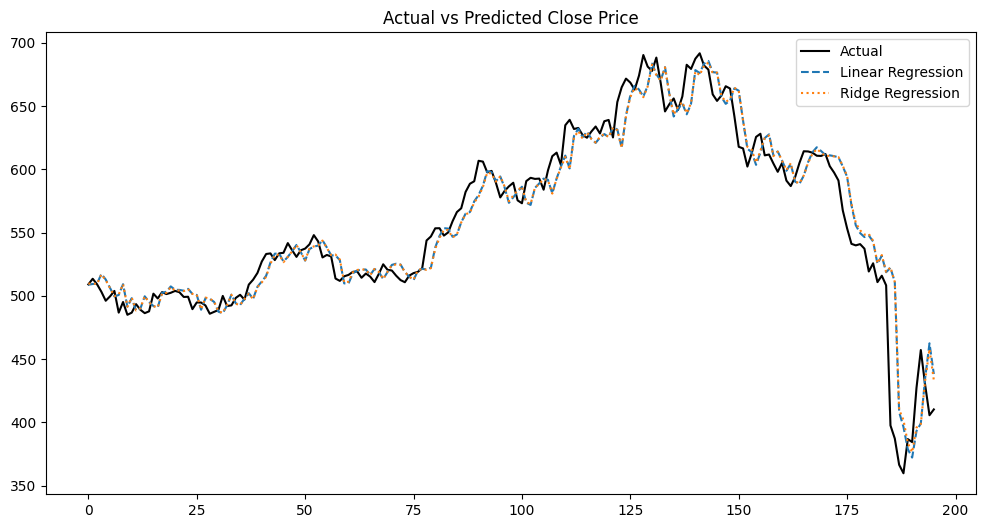

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual', color='black')
plt.plot(y_pred_linear, label='Linear Regression', linestyle='--')
plt.plot(y_pred_ridge, label='Ridge Regression', linestyle=':')

plt.legend()
plt.title("Actual vs Predicted Close Price")
plt.show()

Both Linear Regression and Ridge Regression achieved strong predictive performance, with R² values above 0.91, indicating that the models explain over 91% of the variance in next-day closing prices. The MAE of approximately $13 suggests relatively low average prediction error compared to the overall price range. Ridge regression did not significantly outperform ordinary least squares, suggesting that multicollinearity among engineered features does not heavily impact model stability in this setup. The models successfully capture overall trends but exhibit slight lag during sharp market movements, such as the 2022 downturn, which is expected given the linear nature of the approach.

Linear Regression:

MAE ≈ 13

RMSE ≈ 20

R² ≈ 0.918

Interpretation:

✔ R² above 0.90 → Model explains ~92% of variance

✔ Error ~2–3% of average stock price → Low relative error

✔ Predictions visually track trend well

The Linear Regression model achieved strong predictive performance with an R² of approximately 0.91 and relatively low prediction error compared to the overall price range. The model successfully captures short-term price dynamics and generalizes well to unseen data. Given the constraints of using a linear approach without advanced time-series techniques, the results demonstrate that the model performs effectively for next-day stock price prediction.

In [ ]:
# model_package = {
#     "model": linear,
#     "scaler": scaler
# }

# with open("stock_price_model.pkl", "wb") as f:
#     pickle.dump(model_package, f)